# IFN509 Assessment Item 2 - Exploration of a Large Dataset for Building a Predictive Model
### Group 9
| Student Name | Student Number|
| -------------|---------------|
| Nguyen Khanh Toan Tran | 12939099 |
| Hudson Smith | 12953954 |
| Hieu Pham | 11463333 |

## Loading Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

In [26]:
raw_data = pd.read_csv('dataset.csv')

## Task 1 - Examining data types

In [40]:
raw_data['weight'].unique()

<StringArray>
[        '?',  '[75-100)',   '[50-75)',    '[0-25)', '[100-125)',   '[25-50)',
 '[125-150)', '[175-200)', '[150-175)',      '>200']
Length: 10, dtype: str

In [27]:
raw_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,length_of_stay,...,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,insulin,change,diabetesMed,readmitted,single_day_admission
0,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,No,Steady,No,No,Steady,Ch,Yes,NO,No
1,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,No,No,No,No,Steady,Ch,Yes,NO,No
2,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,Steady,No,No,Steady,Ch,Yes,NO,Yes
3,28236,89869032,AfricanAmerican,Female,[40-50),?,1,1,7,9,...,No,No,No,No,No,Steady,No,Yes,>30,No
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,No,No,No,No,Steady,No,Yes,>30,No


In [28]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50031 entries, 0 to 50030
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              50031 non-null  int64 
 1   patient_nbr               50031 non-null  int64 
 2   race                      50031 non-null  str   
 3   gender                    50031 non-null  str   
 4   age                       50031 non-null  str   
 5   weight                    50031 non-null  str   
 6   admission_type_id         50031 non-null  int64 
 7   discharge_disposition_id  50031 non-null  int64 
 8   admission_source_id       50031 non-null  int64 
 9   length_of_stay            50031 non-null  int64 
 10  payer_code                50031 non-null  str   
 11  medical_specialty         50031 non-null  str   
 12  num_lab_procedures        50031 non-null  int64 
 13  num_procedures            50031 non-null  int64 
 14  num_medications           50031 n

| No. | Variable Name | Expected Data Type | Actual Data Type |
|-----|---------------|--------------------|------------------|
|1|encounter_id|int|int|
|2|patient_nbr|int|int|
|3|race|str|str|
|4|gender|str|str|
|5|age|str|str|
|6|weight|str|str|
|7|admission_type_id|int|int|
|8|discharge_disposition_id|int|int|
|9|admission_source_id|int|int|
|10|length_of_stay|int|int|
|11|payer_code|int|int|
|12|medical_specialty|str|str|
|13|num_lab_procedures|int|int|
|14|num_procedures|int|int|
|15|num_medications|int|int|
|16|number_outpatient|int|*object*|
|17|number_emergency|int|*object*|
|18|number_inpatient|int|*object*|
|19|diag_1|str|str|
|20|diag_2|str|str|
|21|diag_3|str|str|
|22|number_diagnoses|int|int|
|23|diabetes|boolean|*str*|
|24|max_glu_serum|str|str|
|25|A1Cresult|str|str|
|26|metformin|str|str|
|27|repaglinide|str|str|
|28|nateglinide|str|str|
|29|chlorpropamide|str|str|
|30|glimepiride|str|str|
|31|acetohexamide|str|str|
|32|glipizide|str|str|
|33|glyburide|str|str|
|34|tolbutamide|str|str|
|35|insulin|str|str|
|36|change|boolean|*str*|
|37|diabetesMed|boolean|*str*|
|38|readmitted|str|str|
|39|single_day_admission|boolean|*str*|

In [29]:
### Exploring mismatched data columns
print("\nColumn: number_outpatient")
print("Data type: ", raw_data['number_outpatient'].dtype)
print("Unique values: ", raw_data['number_outpatient'].unique())

print("\nColumn: number_emergency")
print("Data type: ", raw_data['number_emergency'].dtype)
print("Unique values: ", raw_data['number_emergency'].unique())

print("\nColumn: number_inpatient")
print("Data type: ", raw_data['number_inpatient'].dtype)
print("Unique values: ", raw_data['number_inpatient'].unique())

print("\nColumn: diabetes")
print("Data type: ", raw_data['diabetes'].dtype)
print("Unique values: ", raw_data['diabetes'].unique())

print("\nColumn: change")
print("Data type: ", raw_data['change'].dtype)
print("Unique values: ", raw_data['change'].unique())

print("\nColumn: diabetesMed")
print("Data type: ", raw_data['diabetesMed'].dtype)
print("Unique values: ", raw_data['diabetesMed'].unique())

print("\nColumn: single_day_admission")
print("Data type: ", raw_data['single_day_admission'].dtype)
print("Unique values: ", raw_data['single_day_admission'].unique())


Column: number_outpatient
Data type:  object
Unique values:  ['0' '2' '1' '?' '5' '7' '9' '3' '8' '4' '12' '11' '6' '20' '15' '10' 0 1
 5 2 4 3 6 12 8 7 13 10 14 9 16 15 21 11 35 17 29 36]

Column: number_emergency
Data type:  object
Unique values:  ['0' '1' '?' '2' '4' '3' '9' '5' '7' '6' '8' '22' '25' '10' '13' '42' '16'
 '11' '28' 0 10 1 3 2 4 5 8]

Column: number_inpatient
Data type:  object
Unique values:  ['0' '1' '2' '3' '6' '?' '5' '4' '7' '8' '9' '15' '10' '11' '14' 0 1 2 5 3
 4 6 10 7 8 9 11 12 13 17 14 15 16 21 18]

Column: diabetes
Data type:  str
Unique values:  <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: change
Data type:  str
Unique values:  <StringArray>
['Ch', 'No']
Length: 2, dtype: str

Column: diabetesMed
Data type:  str
Unique values:  <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: single_day_admission
Data type:  str
Unique values:  <StringArray>
['No', 'Yes']
Length: 2, dtype: str


**Mismatched Variables**
- `number_outpatient`, `number_inpatient` and `number_emergency` - recorded as `object`, upon closer inspection, contained both `str` and `int`. Since these variables represent the numbers of outpatient, inpatient and emergency visits of the patient, they should be corrected to `int`, or more specifically `Int64` to account for missing values.

- `diabetes`, `change`, `diabetesMed` and `single_day_admission` - recorded as `str`. Since these variables only have **2** possible values each, it is better to represent them as `boolean`. However, they cannot be changed directly in this task as they require value-mapping, hence, the type will be corrected in *Task 3*.

In [30]:
### Changing data types for mismatched columns
raw_data['number_outpatient'] = pd.to_numeric(raw_data['number_outpatient'], errors='coerce').astype('Int64')
raw_data['number_emergency'] = pd.to_numeric(raw_data['number_emergency'], errors='coerce').astype('Int64')
raw_data['number_inpatient'] = pd.to_numeric(raw_data['number_inpatient'], errors='coerce').astype('Int64')

# Checking data types after conversion
print("\nAfter conversion:")
print("\nColumn: number_outpatient")
print("Data type: ", raw_data['number_outpatient'].dtype)
print("\nColumn: number_emergency")
print("Data type: ", raw_data['number_emergency'].dtype)
print("\nColumn: number_inpatient")
print("Data type: ", raw_data['number_inpatient'].dtype)



After conversion:

Column: number_outpatient
Data type:  Int64

Column: number_emergency
Data type:  Int64

Column: number_inpatient
Data type:  Int64


## Task 2 - Data Exploration

##### Plotting numerical values

In [31]:
### Remove 'encounter_id' and 'patient_nbr' from the dataset as it is not useful for analysis
raw_data.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)

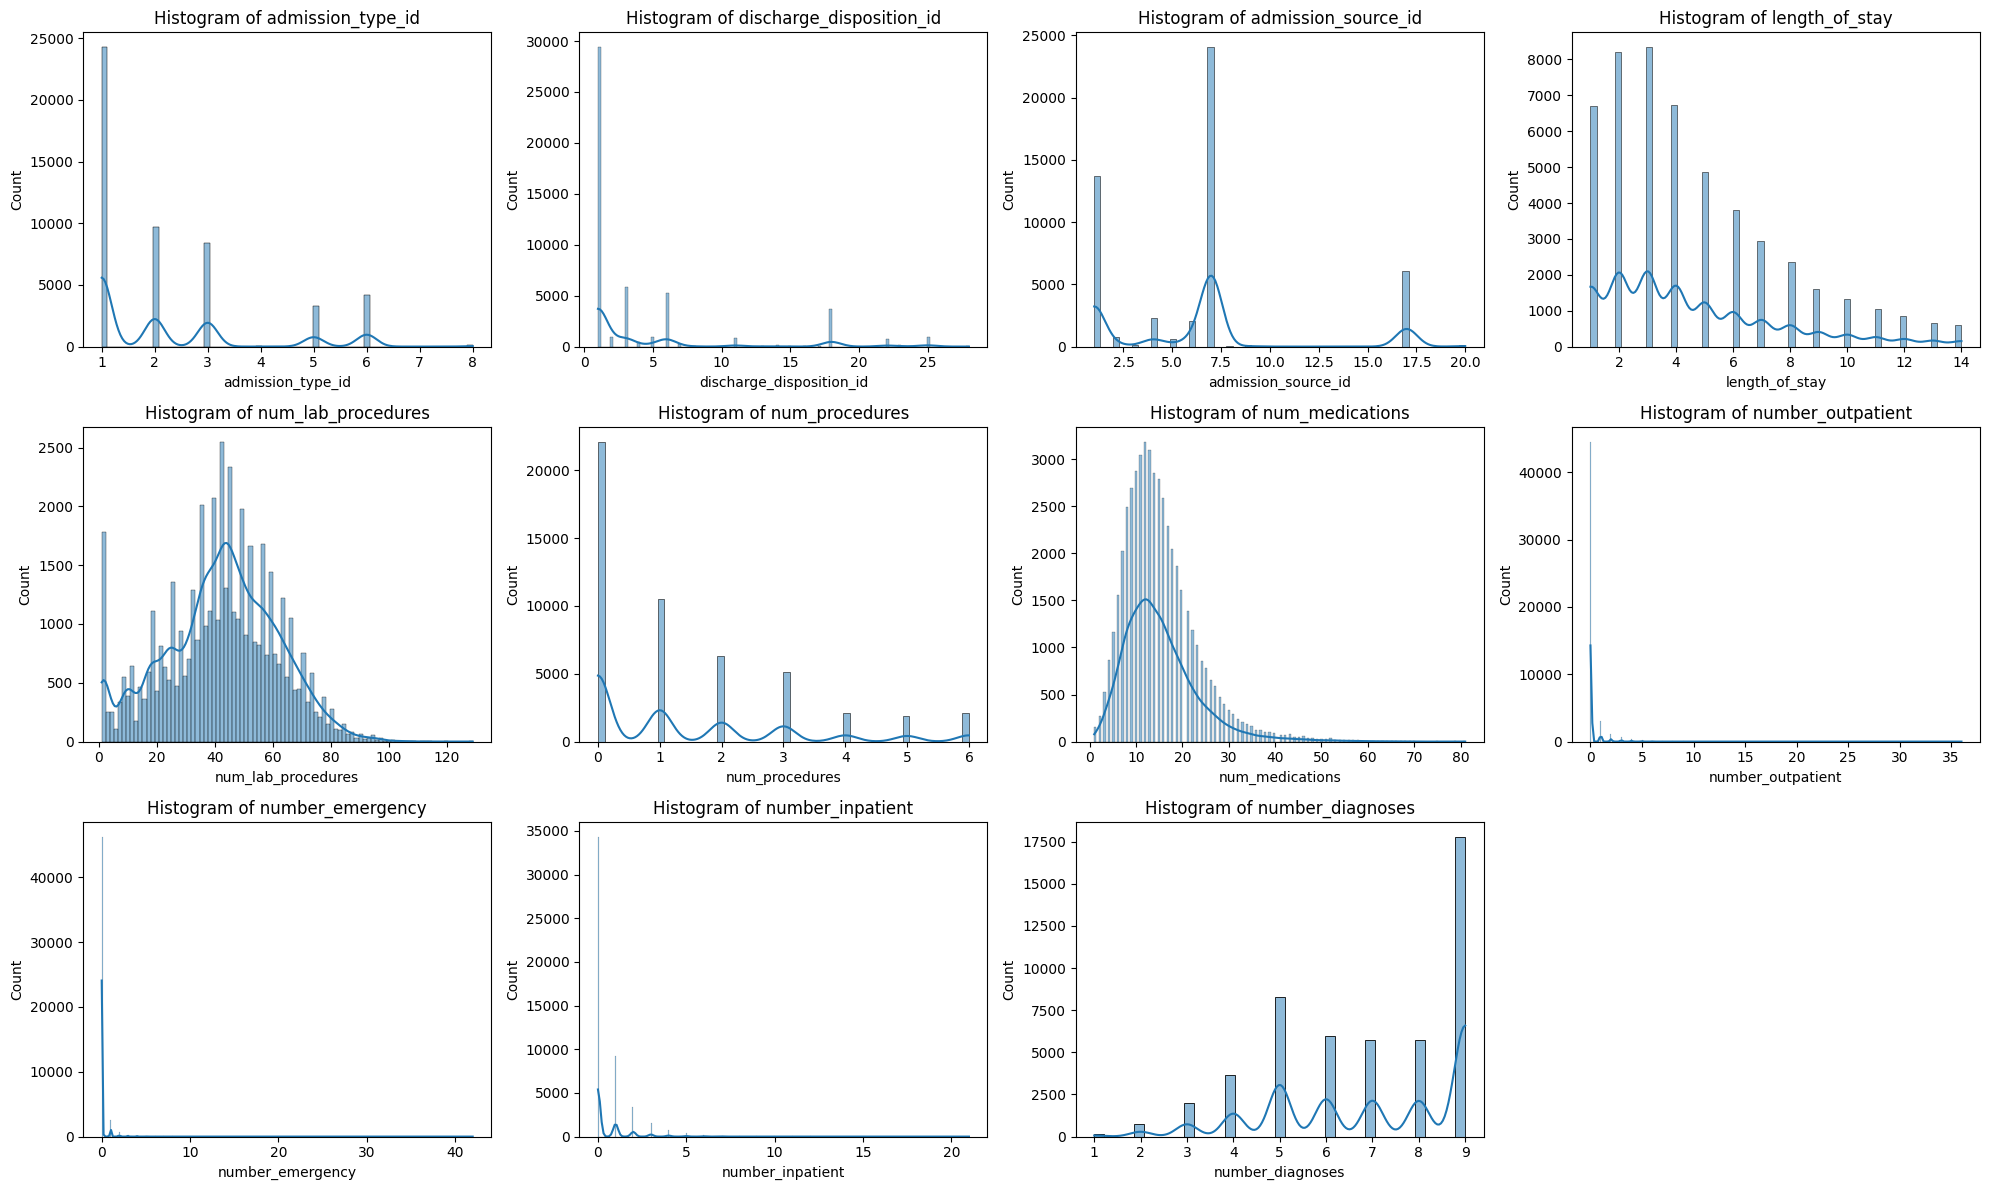

In [38]:
### Histograms of numerical columns
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flatten(), raw_data.select_dtypes(include=[np.number]).columns):
    sns.histplot(raw_data[col], ax=ax, kde=True)
    ax.set_title(f'Histogram of {col}')

for ax in axes.flat[len(raw_data.select_dtypes(include=[np.number]).columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

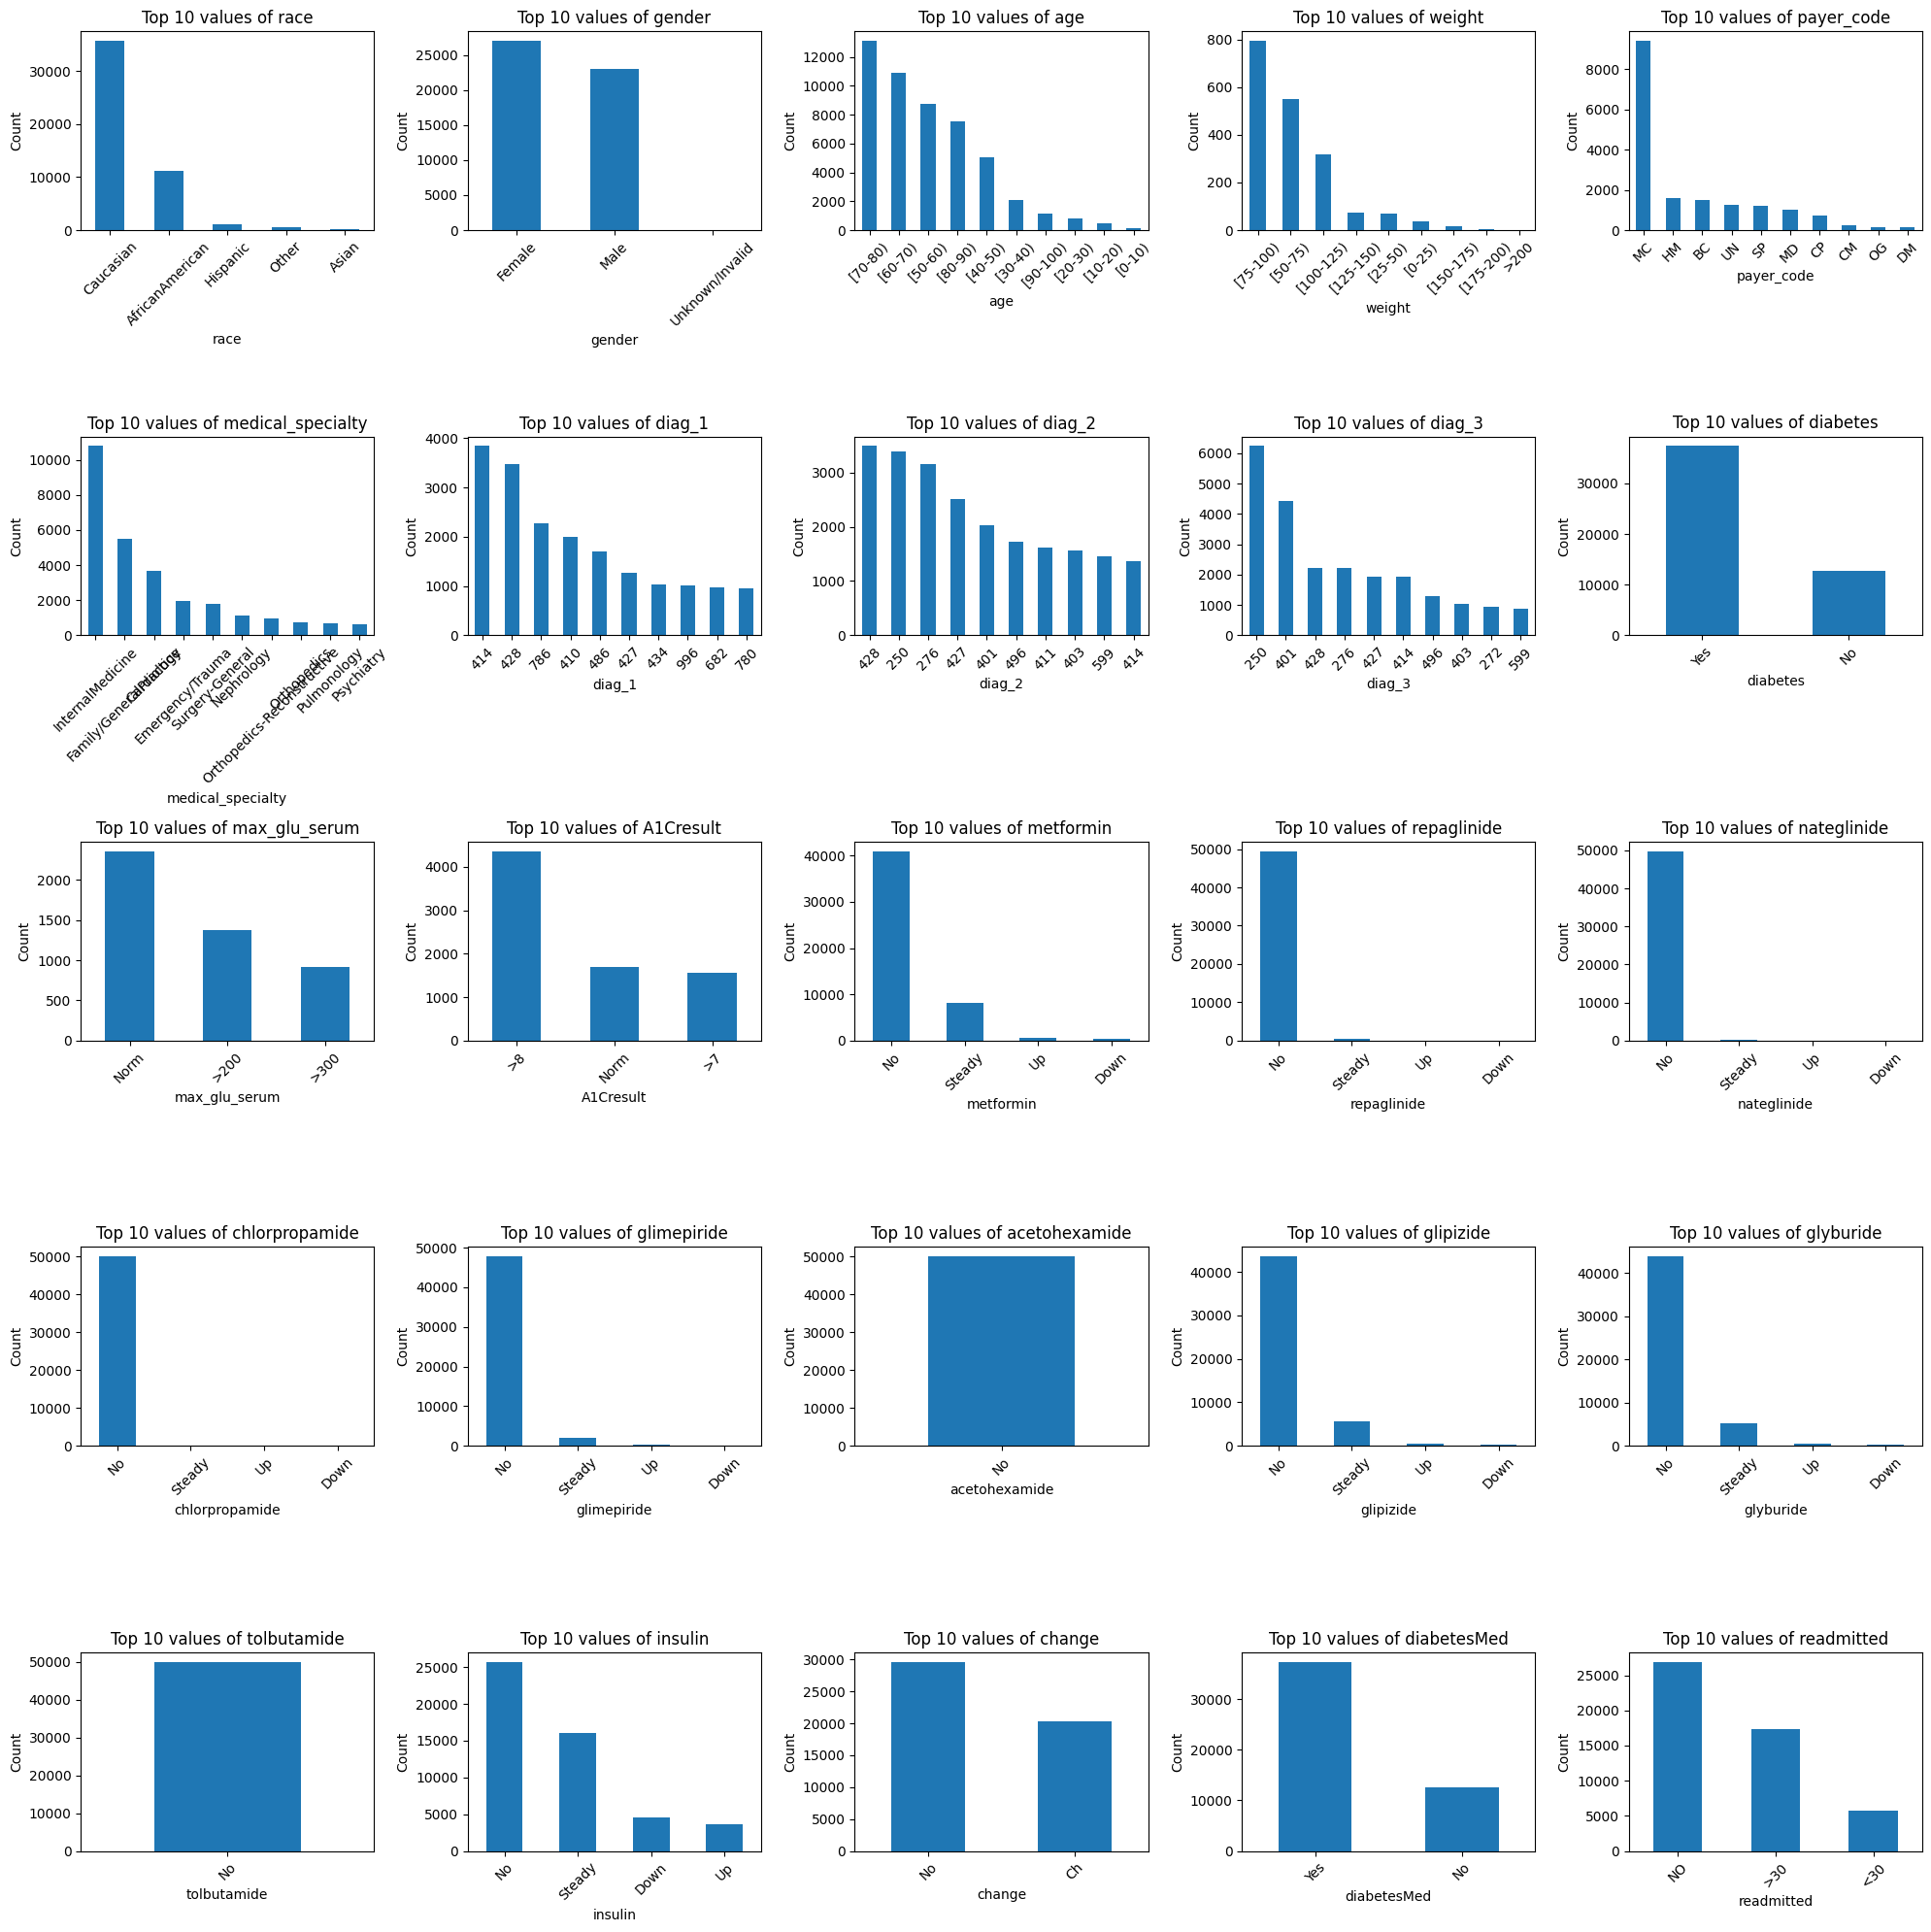

In [ ]:
### Plotting categorical values
cat_cols = raw_data.select_dtypes(include=['str']).columns
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = raw_data.loc[raw_data[col] != '?', col].value_counts().head(10) # Remove '?' values and get top 10 counts
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'Top 10 values of {col}')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

##### Investigating extreme values/outliers

Looking at the plots, there are some extreme values present in many variables, particularly in `number_outpatient`, `number_inpatient` and `number_emergency` for the numerical columns.

For the categorical columns, extreme values are recorded where one value has the majority of the samples, making it rather difficult to examine the distribution of all possible values. These are present in `metformin`, `repaglinide`, `nateglinide`, `chlorpropamide`, `glimepiride`, `glipizide`, `glyburide`.